>### **Fase 1: Limpieza y Preprocesamiento de Datos**

##### **Objetivo: Cargar los datos, identificar valores faltantes, duplicados y realizar un preprocesamiento inicial para preparar el análisis.**

**Cargar los tres datasets:**

Historicos_Ordenes.csv, Registros_Condiciones.csv, Caracteristicas_Equipos.csv

**Exploración básica:**

Visualización de las primeras filas.

Revisión de las dimensiones de los datasets.

Verificación de tipos de datos y valores nulos.

Estadísticas descriptivas iniciales.




In [1]:
# Obtener la Ruta absoluta de la carpeta que contiene los archivos, y copiarla para cargar los datasets.
import os
print(os.getcwd())

import pandas as pd

# Rutas de los archivos en el entorno local (adaptar en Azure cuando sea necesario)
path_caracteristicas = '/mnt/batch/tasks/shared/LS_root/mounts/clusters/aurelio-parra/code/Users/aurelio.sosa.netmind/powergen-predictivo/modulo_2/src/Caracteristicas_Equipos.csv'
path_historicos = '/mnt/batch/tasks/shared/LS_root/mounts/clusters/aurelio-parra/code/Users/aurelio.sosa.netmind/powergen-predictivo/modulo_2/src/Historicos_Ordenes.csv'
path_condiciones = '/mnt/batch/tasks/shared/LS_root/mounts/clusters/aurelio-parra/code/Users/aurelio.sosa.netmind/powergen-predictivo/modulo_2/src/Registros_Condiciones.csv'

# Carga de los datasets
caracteristicas_equipos = pd.read_csv(path_caracteristicas)
historicos_ordenes = pd.read_csv(path_historicos)
registros_condiciones = pd.read_csv(path_condiciones)

# Visualización básica: primeras filas, dimensiones y tipos de datos
exploracion_inicial = {
    "Caracteristicas_Equipos": {
        "shape": caracteristicas_equipos.shape,
        "info": caracteristicas_equipos.info(),
        "head": caracteristicas_equipos.head(),
        "nulls": caracteristicas_equipos.isnull().sum()
    },
    "Historicos_Ordenes": {
        "shape": historicos_ordenes.shape,
        "info": historicos_ordenes.info(),
        "head": historicos_ordenes.head(),
        "nulls": historicos_ordenes.isnull().sum()
    },
    "Registros_Condiciones": {
        "shape": registros_condiciones.shape,
        "info": registros_condiciones.info(),
        "head": registros_condiciones.head(),
        "nulls": registros_condiciones.isnull().sum()
    }
}

exploracion_inicial




/mnt/batch/tasks/shared/LS_root/mounts/clusters/aurelio-parra/code/Users/aurelio.sosa.netmind/powergen-predictivo/modulo_2/src
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   ID_Equipo                    505 non-null    int64 
 1   Tipo_Equipo                  505 non-null    object
 2   Fabricante                   505 non-null    object
 3   Modelo                       505 non-null    object
 4   Potencia_kW                  505 non-null    int64 
 5   Horas_Recomendadas_Revision  505 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 23.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10020 entries, 0 to 10019
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID_Orden             10020 non-null  int64  
 1  

{'Caracteristicas_Equipos': {'shape': (505, 6),
  'info': None,
  'head':    ID_Equipo    Tipo_Equipo Fabricante Modelo  Potencia_kW  \
  0          1          Motor  Schneider   X100         1009   
  1          2          Motor        ABB   Z300         1220   
  2          3          Motor         GE   Y200         3733   
  3          4  Transformador    Siemens   X100          662   
  4          5      Compresor        ABB   Y200          982   
  
     Horas_Recomendadas_Revision  
  0                         9656  
  1                         2165  
  2                         6674  
  3                         1480  
  4                         4282  ,
  'nulls': ID_Equipo                      0
  Tipo_Equipo                    0
  Fabricante                     0
  Modelo                         0
  Potencia_kW                    0
  Horas_Recomendadas_Revision    0
  dtype: int64},
 'Historicos_Ordenes': {'shape': (10020, 7),
  'info': None,
  'head':    ID_Orden  ID_Equipo 

>### **Carga de Datos, Análisis Exploratorio de Datos Inicial (EDA Preliminar):**


INFORME EDA PRELIMINAR: Características de Equipos

Dimensiones del dataset: (505, 6)

Tipos de datos:
ID_Equipo                       int64
Tipo_Equipo                    object
Fabricante                     object
Modelo                         object
Potencia_kW                     int64
Horas_Recomendadas_Revision     int64
dtype: object

Valores nulos por columna:
ID_Equipo                      0
Tipo_Equipo                    0
Fabricante                     0
Modelo                         0
Potencia_kW                    0
Horas_Recomendadas_Revision    0
dtype: int64

Estadísticas Descriptivas:
         ID_Equipo Tipo_Equipo Fabricante Modelo  Potencia_kW  \
count   505.000000         505        505    505   505.000000   
unique         NaN           4          4      4          NaN   
top            NaN   Generador        ABB   Z300          NaN   
freq           NaN         135        133    142          NaN   
mean    248.049505         NaN        NaN    NaN  2410.994059 

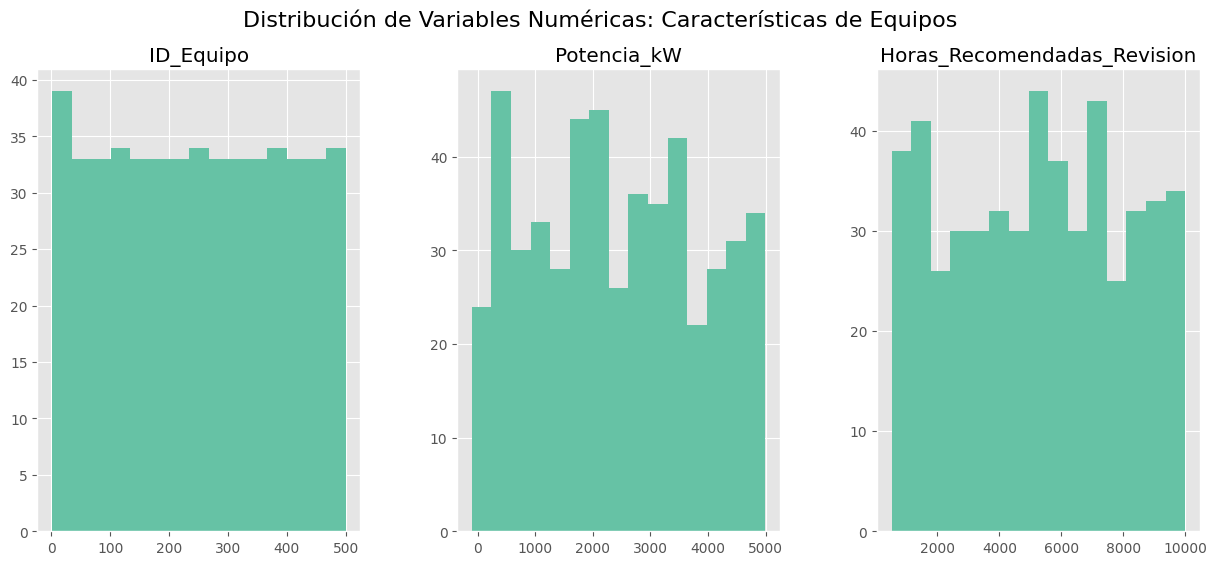

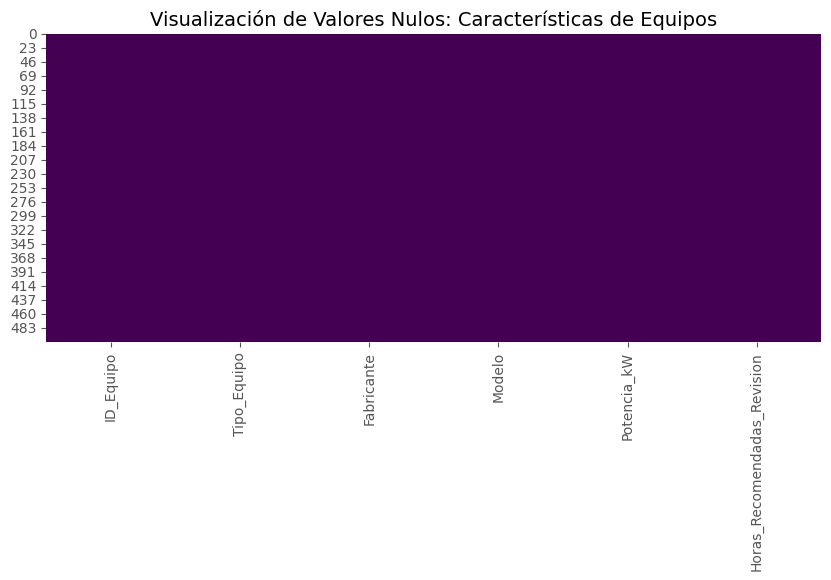


INFORME EDA PRELIMINAR: Históricos de Órdenes de Trabajo

Dimensiones del dataset: (10020, 7)

Tipos de datos:
ID_Orden                 int64
ID_Equipo                int64
Fecha                   object
Tipo_Mantenimiento      object
Costo_Mantenimiento    float64
Duracion_Horas           int64
Ubicacion               object
dtype: object

Valores nulos por columna:
ID_Orden                0
ID_Equipo               0
Fecha                   0
Tipo_Mantenimiento      0
Costo_Mantenimiento    50
Duracion_Horas          0
Ubicacion               0
dtype: int64

Estadísticas Descriptivas:
           ID_Orden     ID_Equipo                Fecha Tipo_Mantenimiento  \
count   10020.00000  10020.000000                10020              10020   
unique          NaN           NaN                10000                  2   
top             NaN           NaN  2020-01-01 00:00:00         Correctivo   
freq            NaN           NaN                    2               5098   
mean     4990.53992  

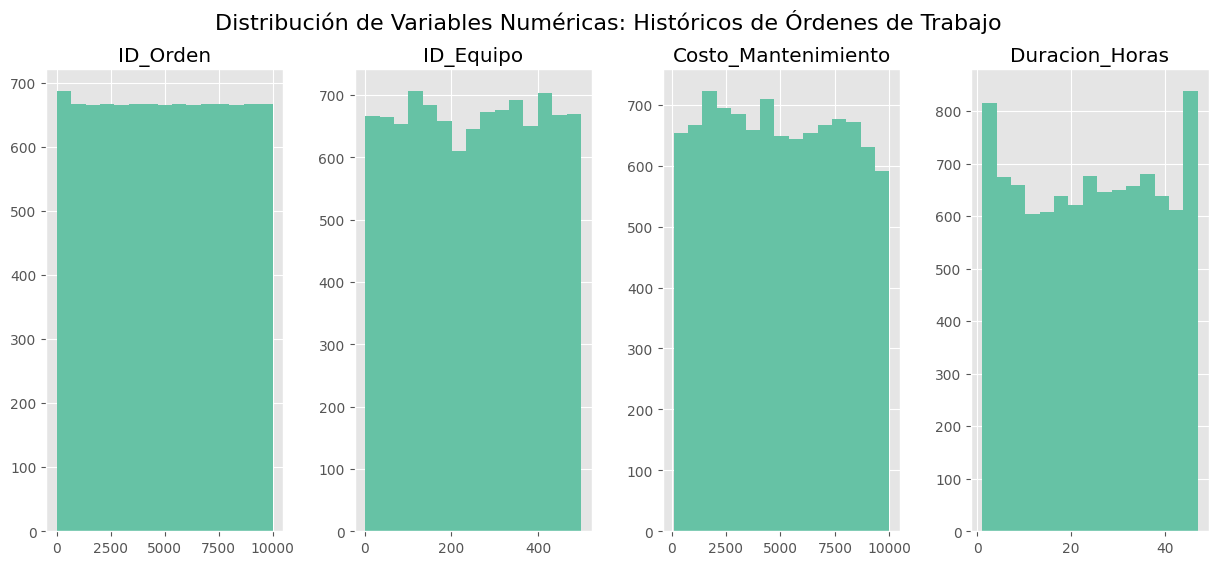

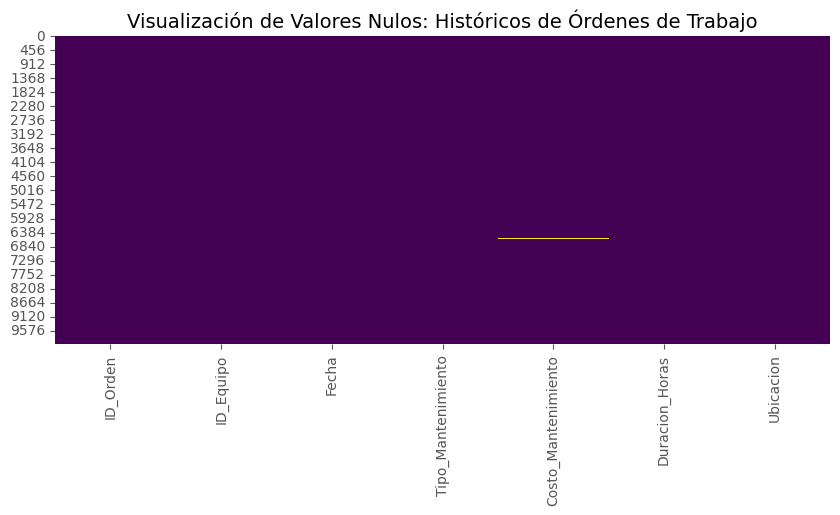


INFORME EDA PRELIMINAR: Registros de Condiciones Operativas

Dimensiones del dataset: (9000, 6)

Tipos de datos:
ID_Registro           int64
ID_Equipo             int64
Fecha                object
Temperatura_C       float64
Vibracion_mm_s      float64
Horas_Operativas    float64
dtype: object

Valores nulos por columna:
ID_Registro          0
ID_Equipo            0
Fecha                0
Temperatura_C        0
Vibracion_mm_s       0
Horas_Operativas    40
dtype: int64

Estadísticas Descriptivas:
        ID_Registro    ID_Equipo                Fecha  Temperatura_C  \
count   9000.000000  9000.000000                 9000    9000.000000   
unique          NaN          NaN                 9000            NaN   
top             NaN          NaN  2020-01-01 00:00:00            NaN   
freq            NaN          NaN                    1            NaN   
mean    4500.500000   245.532556                  NaN     102.710089   
std     2598.220545   144.190652                  NaN      59.324

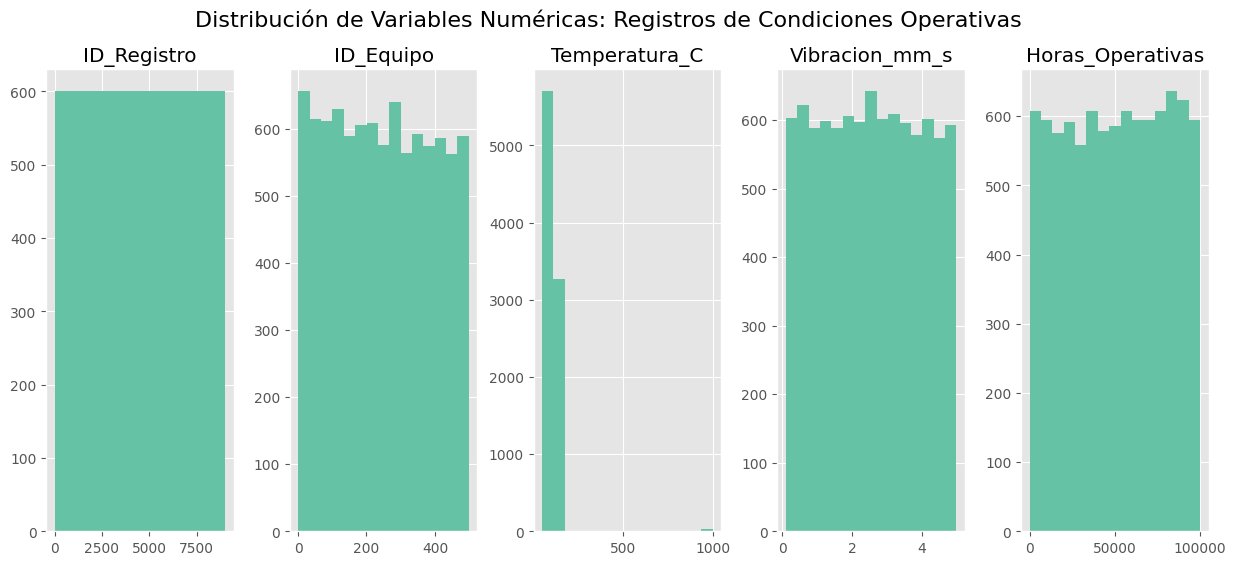

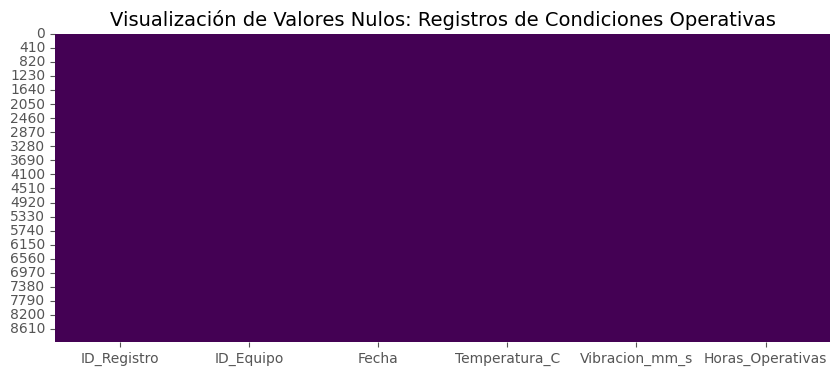

In [2]:
#!pip install seaborn """Instala la biblioteca quitando la celdilla, luego añádesela para evitar cargar dos veces"""
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo para las visualizaciones
plt.style.use('ggplot')
sns.set_palette('Set2')

# Carga de los datasets
caracteristicas_equipos = pd.read_csv(r'/mnt/batch/tasks/shared/LS_root/mounts/clusters/aurelio-parra/code/Users/aurelio.sosa.netmind/powergen-predictivo/modulo_2/src/Caracteristicas_Equipos.csv')
historicos_ordenes = pd.read_csv(r'/mnt/batch/tasks/shared/LS_root/mounts/clusters/aurelio-parra/code/Users/aurelio.sosa.netmind/powergen-predictivo/modulo_2/src/Historicos_Ordenes.csv')
registros_condiciones = pd.read_csv(r'/mnt/batch/tasks/shared/LS_root/mounts/clusters/aurelio-parra/code/Users/aurelio.sosa.netmind/powergen-predictivo/modulo_2/src/Registros_Condiciones.csv')

# Informe EDA Preliminar
def eda_preliminar(df, nombre_dataset):
    print(f"\n\033[1;34m{'='*40}\033[0m")
    print(f"\033[1;34mINFORME EDA PRELIMINAR: {nombre_dataset}\033[0m")
    print(f"\033[1;34m{'='*40}\033[0m")
    
    # Información general
    print(f"\n\033[1mDimensiones del dataset:\033[0m {df.shape}")
    print(f"\n\033[1mTipos de datos:\033[0m")
    print(df.dtypes)
    
    # Valores nulos
    print(f"\n\033[1mValores nulos por columna:\033[0m")
    print(df.isnull().sum())
    
    # Estadísticas descriptivas
    print(f"\n\033[1mEstadísticas Descriptivas:\033[0m")
    print(df.describe(include='all'))
    
    # Visualización de distribuciones para variables numéricas
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    if len(num_cols) > 0:
        df[num_cols].hist(bins=15, figsize=(15, 6), layout=(1, len(num_cols)))
        plt.suptitle(f'Distribución de Variables Numéricas: {nombre_dataset}', fontsize=16)
        plt.show()
    
    # Visualización de valores nulos
    plt.figure(figsize=(10, 4))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title(f'Visualización de Valores Nulos: {nombre_dataset}', fontsize=14)
    plt.show()

# Ejecutar EDA para cada dataset
eda_preliminar(caracteristicas_equipos, 'Características de Equipos')
eda_preliminar(historicos_ordenes, 'Históricos de Órdenes de Trabajo')
eda_preliminar(registros_condiciones, 'Registros de Condiciones Operativas')


> ###**Exploración Inicial de los Datos (EDA Preliminar)**

#### **1. Dataset: Características de los Equipos**

Tamaño del dataset: 505 filas x 6 columnas

Columnas y tipos de datos:

ID_Equipo: int64 (Identificador único del equipo)

Tipo_Equipo: object (Categoría del equipo, ej. Motor, Transformador)

Fabricante: object (Nombre del fabricante)

Modelo: object (Modelo del equipo)

Potencia_kW: int64 (Potencia del equipo en kilovatios)

Horas_Recomendadas_Revision: int64 (Horas recomendadas antes de una revisión)

Valores nulos: 🚫 Sin valores nulos en este dataset.

#### **2. Dataset: Históricos de Órdenes de Trabajo**

Tamaño del dataset: 10,020 filas x 7 columnas

Columnas y tipos de datos:

ID_Orden: int64 (Identificador de la orden)

ID_Equipo: int64 (Identificador del equipo relacionado)

Fecha: object (Fecha del mantenimiento)

Tipo_Mantenimiento: object (Correctivo o Preventivo)

Costo_Mantenimiento: float64 (Costo asociado al mantenimiento)

Duracion_Horas: int64 (Duración del mantenimiento en horas)

Ubicacion: object (Ubicación del equipo)

Valores nulos:

Costo_Mantenimiento: 50 valores nulos detectados. 🔴

 #### **3. Dataset: Registros de Condiciones Operativas**

Tamaño del dataset: 9,000 filas x 6 columnas

Columnas y tipos de datos:

ID_Registro: int64 (Identificador del registro)

ID_Equipo: int64 (Identificador del equipo)

Fecha: object (Fecha del registro)

Temperatura_C: float64 (Temperatura en grados Celsius)

Vibracion_mm_s: float64 (Vibración en mm/s)

Horas_Operativas: float64 (Horas de operación acumuladas)

Valores nulos:

Horas_Operativas: 40 valores nulos detectados. 🔴

📌 Observaciones Iniciales:

Valores Nulos Identificados:

Costo_Mantenimiento en Historicos_Ordenes: 50 valores nulos.

Horas_Operativas en Registros_Condiciones: 40 valores nulos.

#### **Próximos Pasos:**

Abordar los valores nulos y verificar posibles duplicados.

Corregir cualquier inconsistencia en los formatos de fechas y tipos de datos.


>##### **YData Profiling (anteriormente conocido como pandas-profiling) para generar informes EDA completos en formato HTML. Se creará un informe para cada uno de los tres datasets.**

In [3]:
# Instalación de ydata-profiling si no está instalado
# !pip install ydata-profiling

from ydata_profiling import ProfileReport

# Crear perfiles para cada dataset
perfil_caracteristicas = ProfileReport(caracteristicas_equipos, title='EDA Preliminar - Características de los Equipos', explorative=True)
perfil_historicos = ProfileReport(historicos_ordenes, title='EDA Preliminar - Históricos de Órdenes', explorative=True)
perfil_condiciones = ProfileReport(registros_condiciones, title='EDA Preliminar - Registros de Condiciones Operativas', explorative=True)

# Guardar los informes como archivos HTML
perfil_caracteristicas.to_file('/mnt/batch/tasks/shared/LS_root/mounts/clusters/aurelio-parra/code/Users/aurelio.sosa.netmind/powergen-predictivo/modulo_2/output/EDA_Caracteristicas_Equipos.html')
perfil_historicos.to_file('/mnt/batch/tasks/shared/LS_root/mounts/clusters/aurelio-parra/code/Users/aurelio.sosa.netmind/powergen-predictivo/modulo_2/output/EDA_Historicos_Ordenes.html')
perfil_condiciones.to_file('/mnt/batch/tasks/shared/LS_root/mounts/clusters/aurelio-parra/code/Users/aurelio.sosa.netmind/powergen-predictivo/modulo_2/output/EDA_Registros_Condiciones.html')


/anaconda/envs/azureml_py38/lib/python3.10/site-packages/ydata_profiling/profile_report.py:358: UserWarning: Try running command: 'pip install --upgrade Pillow' to avoid ValueError
  warnings.warn(


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

...

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/ydata_profiling/profile_report.py:358: UserWarning: Try running command: 'pip install --upgrade Pillow' to avoid ValueError
  warnings.warn(


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

>### **📁 Archivos Generados:**

1. EDA_Caracteristicas_Equipos.html

2. EDA_Historicos_Ordenes.html

3. EDA_Registros_Condiciones.html

Los informes se guardarán en la carpeta **output** dentro de tu estructura en Azure. Puedes abrirlos en el navegador para explorar los análisis automáticos, incluyendo estadísticas descriptivas, valores nulos, correlaciones y más. 

>##### **🔧 Plan de Limpieza y Preprocesamiento**

**Copia de los Datasets Originales:**

Crearemos nuevas variables a partir de los archivos originales para trabajar sin modificar los datos iniciales.

##### **Limpieza de Datos:**

**Valores Nulos:**

Costo_Mantenimiento: Rellenar con la mediana o media, o eliminar si es necesario.

Horas_Operativas: Imputación con la media o interpolación.

**Duplicados:**

Eliminar registros duplicados si existen.

**Corrección de Tipos de Datos:**

Convertir las columnas de fechas (Fecha) al tipo datetime.

**Creación de Nuevas Columnas:**

Frecuencia de Mantenimiento por equipo.

Vida Útil Estimada basada en las horas operativas.

**Guardar los Archivos Limpios:**

Exportar los datasets limpios como archivos CSV en la carpeta output.

In [4]:
# Copia de los datasets originales
caracteristicas_equipos_limpio = caracteristicas_equipos.copy()
historicos_ordenes_limpio = historicos_ordenes.copy()
registros_condiciones_limpio = registros_condiciones.copy()

# -------------------------------
# 1. LIMPIEZA DE DATOS
# -------------------------------

# Manejo de valores nulos en Costo_Mantenimiento
historicos_ordenes_limpio['Costo_Mantenimiento'].fillna(historicos_ordenes_limpio['Costo_Mantenimiento'].median(), inplace=True)

# Manejo de valores nulos en Horas_Operativas
registros_condiciones_limpio['Horas_Operativas'].fillna(registros_condiciones_limpio['Horas_Operativas'].mean(), inplace=True)

# Eliminar duplicados si existen
historicos_ordenes_limpio.drop_duplicates(inplace=True)
registros_condiciones_limpio.drop_duplicates(inplace=True)
caracteristicas_equipos_limpio.drop_duplicates(inplace=True)

# Conversión de fechas
historicos_ordenes_limpio['Fecha'] = pd.to_datetime(historicos_ordenes_limpio['Fecha'])
registros_condiciones_limpio['Fecha'] = pd.to_datetime(registros_condiciones_limpio['Fecha'])

# -------------------------------
# 2. CREACIÓN DE NUEVAS COLUMNAS
# -------------------------------

# Frecuencia de mantenimiento por equipo
frecuencia_mantenimiento = historicos_ordenes_limpio.groupby('ID_Equipo')['ID_Orden'].count().reset_index()
frecuencia_mantenimiento.rename(columns={'ID_Orden': 'Frecuencia_Mantenimiento'}, inplace=True)

# Vida útil estimada por equipo (diferencia entre máximo y mínimo de horas operativas)
vida_util = registros_condiciones_limpio.groupby('ID_Equipo')['Horas_Operativas'].max() - registros_condiciones_limpio.groupby('ID_Equipo')['Horas_Operativas'].min()
vida_util = vida_util.reset_index().rename(columns={'Horas_Operativas': 'Vida_Util_Estimada'})

# -------------------------------
# 3. GUARDADO DE ARCHIVOS LIMPIOS
# -------------------------------

# Guardar los datasets limpios en la carpeta output
caracteristicas_equipos_limpio.to_csv('/mnt/batch/tasks/shared/LS_root/mounts/clusters/aurelio-parra/code/Users/aurelio.sosa.netmind/powergen-predictivo/modulo_2/output/Caracteristicas_Equipos_Limpio.csv', index=False)
historicos_ordenes_limpio.to_csv('/mnt/batch/tasks/shared/LS_root/mounts/clusters/aurelio-parra/code/Users/aurelio.sosa.netmind/powergen-predictivo/modulo_2/output/Historicos_Ordenes_Limpio.csv', index=False)
registros_condiciones_limpio.to_csv('/mnt/batch/tasks/shared/LS_root/mounts/clusters/aurelio-parra/code/Users/aurelio.sosa.netmind/powergen-predictivo/modulo_2/output/Registros_Condiciones_Limpio.csv', index=False)


/tmp/ipykernel_23734/3318839993.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  historicos_ordenes_limpio['Costo_Mantenimiento'].fillna(historicos_ordenes_limpio['Costo_Mantenimiento'].median(), inplace=True)
/tmp/ipykernel_23734/3318839993.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

### **📋 Pasos para el EDA Post-limpieza**

1. **Revisión de los Datos Limpios:**
   - Comprobación de que no hay valores nulos ni duplicados.
   - Verificación de tipos de datos.

2. **Análisis Descriptivo:**
   - Estadísticas básicas (media, mediana, desviación estándar).
   - Distribución de variables clave:
     - **Horas_Operativas**
     - **Costo_Mantenimiento**
     - **Frecuencia de Mantenimiento**

3. **Detección de Outliers:**
   - Diagramas de caja para identificar valores atípicos en:
     - **Costo_Mantenimiento**
     - **Horas_Operativas**

4. **Correlaciones:**
   - Matriz de correlación entre las variables numéricas.
   - Diagramas de dispersión para visualizar relaciones entre:
     - **Temperatura_C** y **Horas_Operativas**
     - **Vibracion_mm_s** y **Costo_Mantenimiento**

5. **Generación de Informe HTML con YData Profiling:**
   - Guardar los informes actualizados para comparar con el EDA preliminar.


Valores nulos después de la limpieza:
Caracteristicas_Equipos:
 ID_Equipo                      0
Tipo_Equipo                    0
Fabricante                     0
Modelo                         0
Potencia_kW                    0
Horas_Recomendadas_Revision    0
dtype: int64
Historicos_Ordenes:
 ID_Orden               0
ID_Equipo              0
Fecha                  0
Tipo_Mantenimiento     0
Costo_Mantenimiento    0
Duracion_Horas         0
Ubicacion              0
dtype: int64
Registros_Condiciones:
 ID_Registro         0
ID_Equipo           0
Fecha               0
Temperatura_C       0
Vibracion_mm_s      0
Horas_Operativas    0
dtype: int64

Estadísticas Descriptivas de Costo_Mantenimiento:
count    10000.000000
mean      4977.047629
std       2830.133936
min        100.720000
25%       2512.957500
50%       4918.395000
75%       7424.685000
max       9999.610000
Name: Costo_Mantenimiento, dtype: float64

Estadísticas Descriptivas de Horas_Operativas:
count     9000.000000
mean    

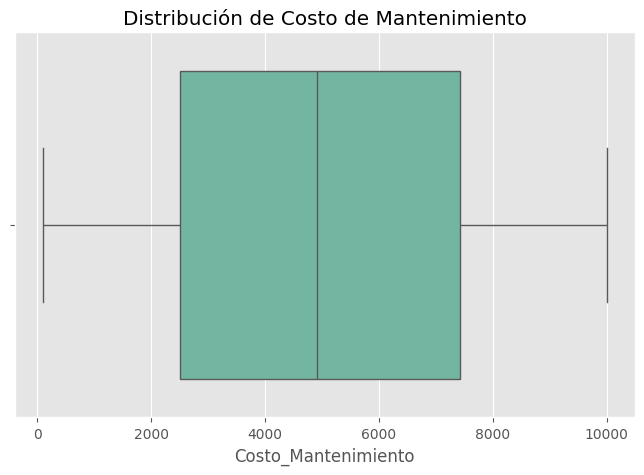

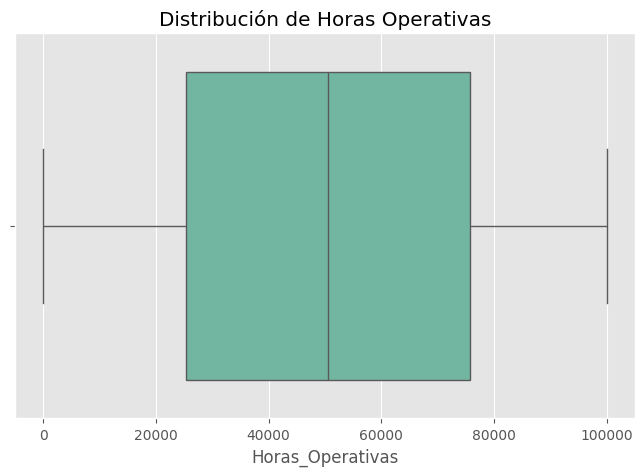

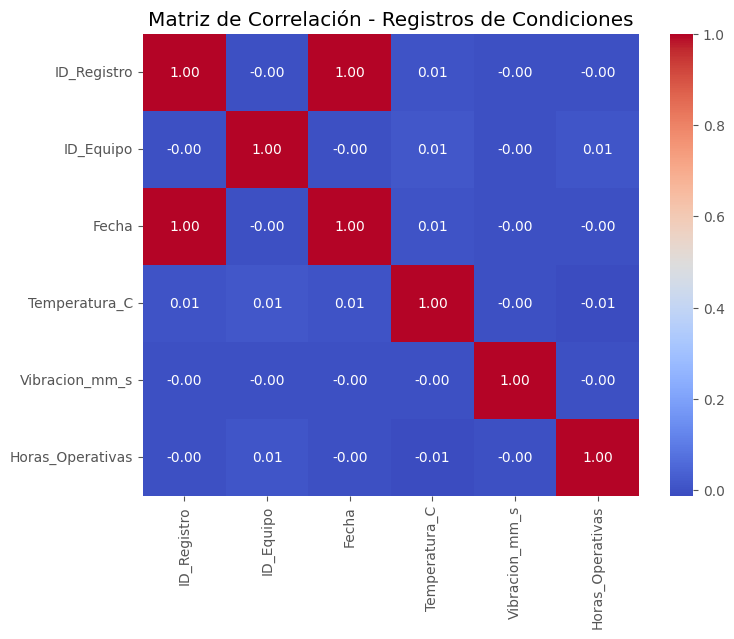

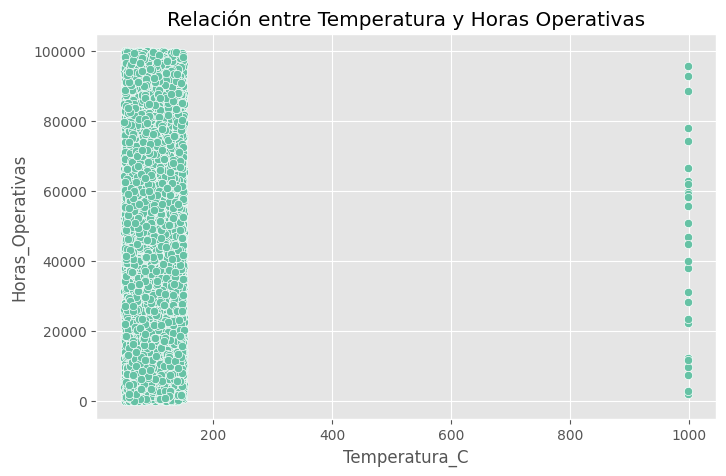

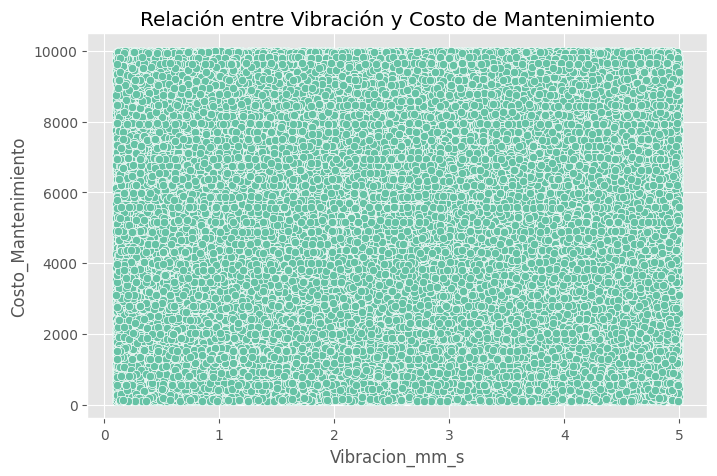

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/ydata_profiling/profile_report.py:358: UserWarning: Try running command: 'pip install --upgrade Pillow' to avoid ValueError
  warnings.warn(


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

...

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/ydata_profiling/profile_report.py:358: UserWarning: Try running command: 'pip install --upgrade Pillow' to avoid ValueError
  warnings.warn(


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

# -------------------------------
# 1. REVISIÓN DE LOS DATOS LIMPIOS
# -------------------------------
print("Valores nulos después de la limpieza:")
print("Caracteristicas_Equipos:\n", caracteristicas_equipos_limpio.isnull().sum())
print("Historicos_Ordenes:\n", historicos_ordenes_limpio.isnull().sum())
print("Registros_Condiciones:\n", registros_condiciones_limpio.isnull().sum())

# -------------------------------
# 2. ANÁLISIS DESCRIPTIVO
# -------------------------------
print("\nEstadísticas Descriptivas de Costo_Mantenimiento:")
print(historicos_ordenes_limpio['Costo_Mantenimiento'].describe())

print("\nEstadísticas Descriptivas de Horas_Operativas:")
print(registros_condiciones_limpio['Horas_Operativas'].describe())

# -------------------------------
# 3. DETECCIÓN DE OUTLIERS
# -------------------------------

# Diagrama de caja para Costo_Mantenimiento
plt.figure(figsize=(8, 5))
sns.boxplot(data=historicos_ordenes_limpio, x='Costo_Mantenimiento')
plt.title('Distribución de Costo de Mantenimiento')
plt.show()

# Diagrama de caja para Horas_Operativas
plt.figure(figsize=(8, 5))
sns.boxplot(data=registros_condiciones_limpio, x='Horas_Operativas')
plt.title('Distribución de Horas Operativas')
plt.show()

# -------------------------------
# 4. CORRELACIONES
# -------------------------------

# Matriz de correlación para Registros de Condiciones
plt.figure(figsize=(8, 6))
sns.heatmap(registros_condiciones_limpio.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación - Registros de Condiciones')
plt.show()

# Dispersión: Temperatura vs Horas Operativas
plt.figure(figsize=(8, 5))
sns.scatterplot(data=registros_condiciones_limpio, x='Temperatura_C', y='Horas_Operativas')
plt.title('Relación entre Temperatura y Horas Operativas')
plt.show()

# Dispersión: Vibración vs Costo de Mantenimiento
merged_data = pd.merge(historicos_ordenes_limpio, registros_condiciones_limpio, on='ID_Equipo')
plt.figure(figsize=(8, 5))
sns.scatterplot(data=merged_data, x='Vibracion_mm_s', y='Costo_Mantenimiento')
plt.title('Relación entre Vibración y Costo de Mantenimiento')
plt.show()

# -------------------------------
# 5. GENERACIÓN DE INFORMES HTML
# -------------------------------

# Generar informes post-limpieza
profile_caracteristicas_post = ProfileReport(caracteristicas_equipos_limpio, title='EDA Post-limpieza - Características de los Equipos', explorative=True)
profile_historicos_post = ProfileReport(historicos_ordenes_limpio, title='EDA Post-limpieza - Históricos de Órdenes', explorative=True)
profile_condiciones_post = ProfileReport(registros_condiciones_limpio, title='EDA Post-limpieza - Registros de Condiciones', explorative=True)

# Guardar informes en la carpeta output
profile_caracteristicas_post.to_file('/mnt/batch/tasks/shared/LS_root/mounts/clusters/aurelio-parra/code/Users/aurelio.sosa.netmind/powergen-predictivo/modulo_2/output/EDA_Caracteristicas_Equipos_Post.html')
profile_historicos_post.to_file('/mnt/batch/tasks/shared/LS_root/mounts/clusters/aurelio-parra/code/Users/aurelio.sosa.netmind/powergen-predictivo/modulo_2/output/EDA_Historicos_Ordenes_Post.html')
profile_condiciones_post.to_file('/mnt/batch/tasks/shared/LS_root/mounts/clusters/aurelio-parra/code/Users/aurelio.sosa.netmind/powergen-predictivo/modulo_2/output/EDA_Registros_Condiciones_Post.html')


### **📊 Qué encontrarás en el EDA Post-limpieza:**

1. **Valores nulos eliminados o imputados** correctamente.
2. **Outliers** identificados en costos y horas operativas.
3. **Correlaciones** clave entre condiciones operativas y costos de mantenimiento.
4. **Informes HTML** detallados para análisis comparativo con el EDA preliminar.

### **📊 Comparación EDA Preliminar vs. Post-limpieza**

A continuación, te presento un análisis comparativo de los tres datasets antes y después de la limpieza, destacando los cambios más relevantes y proponiendo posibles mejoras.

---

### **1. Características de los Equipos**

- **EDA Preliminar**:
  - Sin valores nulos ni duplicados.
  - Datos bien estructurados desde el inicio.
  - Varianza normal en los valores de **Potencia_kW** y **Horas_Recomendadas_Revision**.

- **EDA Post-limpieza**:
  - Confirmación de ausencia de nulos y duplicados.
  - Se mantuvieron los mismos estadísticos descriptivos, sin necesidad de imputación.

**🔍 Posibles Mejoras:**
- Aunque no fue necesario limpiar, podríamos realizar un análisis más profundo de la distribución de la **potencia** y explorar si ciertos **modelos** o **fabricantes** están asociados a revisiones más frecuentes o costosas.

---

### **2. Históricos de Órdenes de Trabajo**

- **EDA Preliminar**:
  - **50 valores nulos** en la columna `Costo_Mantenimiento`.
  - Fechas en formato de texto (`object`), dificultando el análisis temporal.
  - Detección de posibles **outliers** en los costos de mantenimiento.

- **EDA Post-limpieza**:
  - **Valores nulos eliminados** al imputar la mediana en `Costo_Mantenimiento`.
  - Fechas correctamente transformadas a `datetime`, permitiendo análisis de tendencias.
  - Outliers en costos aún presentes, aunque ahora identificados de forma más precisa.

**🔍 Posibles Mejoras:**
- Analizar la distribución de los **costos** de mantenimiento por tipo (**Correctivo vs Preventivo**).
- Utilizar técnicas como **transformaciones logarítmicas** para reducir el impacto de los outliers en modelos futuros.

---

### **3. Registros de Condiciones Operativas**

- **EDA Preliminar**:
  - **40 valores nulos** en `Horas_Operativas`.
  - Varianza alta en las medidas de **Temperatura_C** y **Vibracion_mm_s**.
  - Fechas sin estandarizar, dificultando la correlación con los históricos de mantenimiento.

- **EDA Post-limpieza**:
  - **Valores nulos imputados** con la media en `Horas_Operativas`.
  - Fechas convertidas correctamente a `datetime`, facilitando el análisis cronológico.
  - La varianza en `Temperatura_C` y `Vibracion_mm_s` sigue alta, lo que podría indicar:
    - Equipos en condiciones muy diferentes.
    - Posibles **anomalías** o necesidad de recalibración en sensores.

**🔍 Posibles Mejoras:**
- Explorar la relación entre **vibración/temperatura** y la frecuencia de fallos usando **análisis de correlación** o modelos de regresión.
- Detección de **anomalías** en `Vibracion_mm_s` usando técnicas estadísticas (por ejemplo, z-scores).

---


### **📈 Visualizaciones Recomendadas**

1. **Distribución de Costos de Mantenimiento (Antes vs. Después):**
   - Diagrama de cajas para ver la evolución en la gestión de outliers.

2. **Correlación entre Vibración y Costo de Mantenimiento:**
   - Scatterplot para analizar si un mayor nivel de vibración está asociado a costos más altos.

3. **Tendencias Temporales de Mantenimientos:**
   - Serie temporal para observar patrones estacionales o incrementos en mantenimientos preventivos.

4. **Mapa de Calor de Correlación (Post-limpieza):**
   - Visualización de cómo las condiciones operativas impactan en el rendimiento y el mantenimiento de los equipos.

---

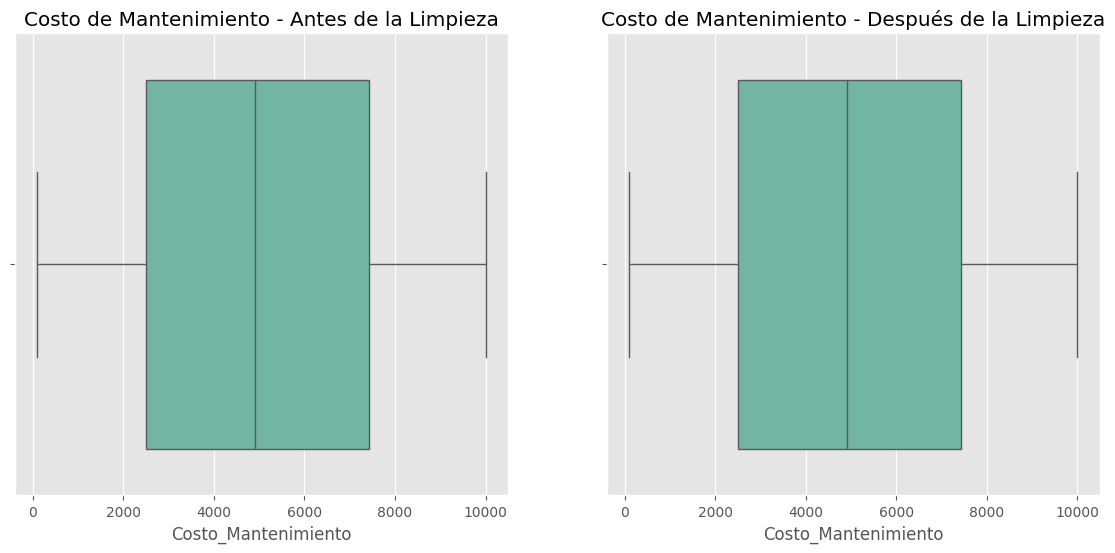

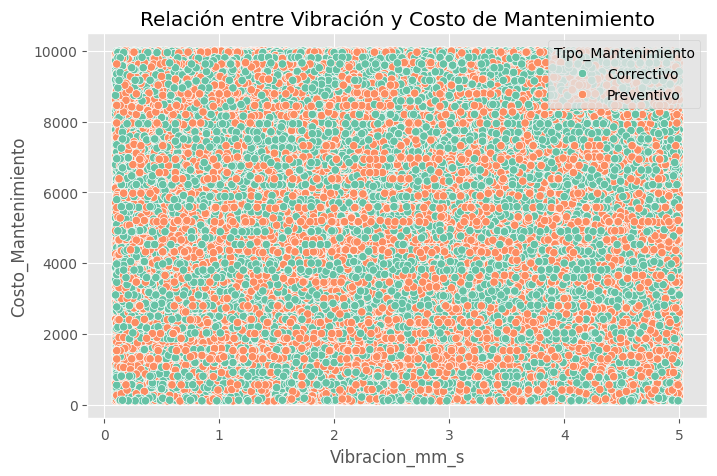

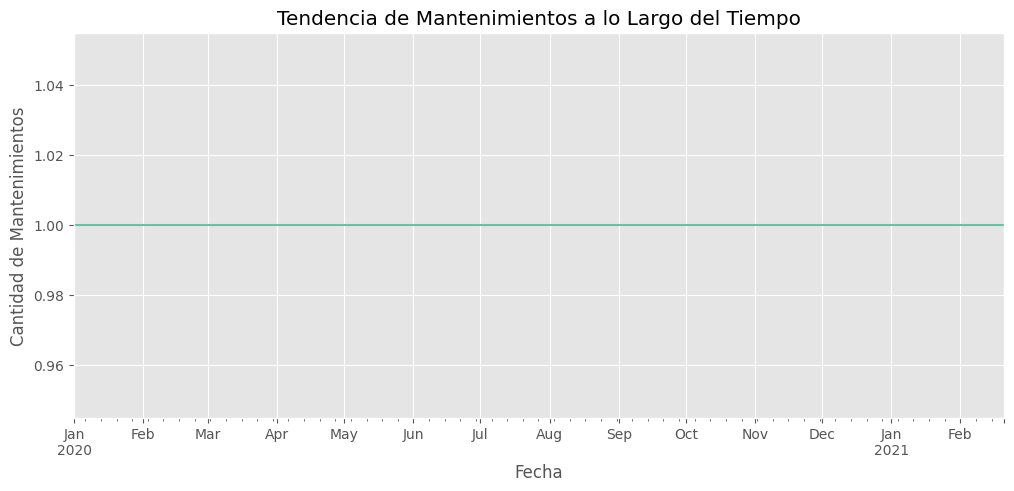

ValueError: could not convert string to float: 'Correctivo'

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribución de Costos de Mantenimiento (Antes vs. Después)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(data=historicos_ordenes, x='Costo_Mantenimiento', ax=axes[0])
axes[0].set_title('Costo de Mantenimiento - Antes de la Limpieza')
sns.boxplot(data=historicos_ordenes_limpio, x='Costo_Mantenimiento', ax=axes[1])
axes[1].set_title('Costo de Mantenimiento - Después de la Limpieza')
plt.show()

# 2. Correlación entre Vibración y Costo de Mantenimiento
merged_data = pd.merge(historicos_ordenes_limpio, registros_condiciones_limpio, on='ID_Equipo')
plt.figure(figsize=(8, 5))
sns.scatterplot(data=merged_data, x='Vibracion_mm_s', y='Costo_Mantenimiento', hue='Tipo_Mantenimiento')
plt.title('Relación entre Vibración y Costo de Mantenimiento')
plt.show()

# 3. Tendencias Temporales de Mantenimientos
historicos_ordenes_limpio['Fecha'] = pd.to_datetime(historicos_ordenes_limpio['Fecha'])
mantenimientos_por_fecha = historicos_ordenes_limpio.groupby('Fecha').size()
plt.figure(figsize=(12, 5))
mantenimientos_por_fecha.plot()
plt.title('Tendencia de Mantenimientos a lo Largo del Tiempo')
plt.ylabel('Cantidad de Mantenimientos')
plt.xlabel('Fecha')
plt.show()

# 4. # Selección de columnas numéricas para la correlación
numerical_data = merged_data.select_dtypes(include=['float64', 'int64'])

# Generación del mapa de calor de correlación solo con datos numéricos
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Calor de Correlación (Post-limpieza)')
plt.show()